In [87]:
%pip install xlrd

Note: you may need to restart the kernel to use updated packages.


# Predictive Modeling of Real Estate Pricing

In [88]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\LOQ\OneDrive\Desktop\REGRESSION1
['real_estate_S.xlsx', 'Regression_project2 (1) (1).ipynb', 'Regression_Report.docx', 'X_test.xlsx', 'X_train.xlsx', 'y_test.xlsx', 'y_train.xlsx']


In [89]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
df = pd.read_excel("real_estate_S.xlsx")

In [90]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age,Neighborhood,Property_Type,Garage_Type,Has_Pool,Distance_to_Center,Price
0,2761.0,3,1,24,Beach,House,Attached,No,8.1,549118
1,1973.0,4,2,35,Downtown,Apartment,Attached,No,15.8,520515
2,2616.0,3,1,22,Industrial,Apartment,NaN,Yes,10.5,533105
3,2984.0,3,2,17,Rural,Townhouse,Attached,No,6.2,613158
4,1938.0,2,2,26,Beach,Apartment,Detached,No,11.2,489302


In [91]:
df.shape

(800, 10)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Area_sqft           729 non-null    float64
 1   Bedrooms            800 non-null    int64  
 2   Bathrooms           800 non-null    int64  
 3   Age                 800 non-null    int64  
 4   Neighborhood        800 non-null    object 
 5   Property_Type       800 non-null    object 
 6   Garage_Type         547 non-null    object 
 7   Has_Pool            800 non-null    object 
 8   Distance_to_Center  800 non-null    float64
 9   Price               800 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 62.6+ KB


## Data Preprocessing

In [93]:
print("\nMissing Values per Column:\n", df.isnull().sum())


Missing Values per Column:
 Area_sqft              71
Bedrooms                0
Bathrooms               0
Age                     0
Neighborhood            0
Property_Type           0
Garage_Type           253
Has_Pool                0
Distance_to_Center      0
Price                   0
dtype: int64


In [94]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_Center,Price
count,729.000000,800.000000,800.000000,800.00000,800.000000,800.000000
mean,2228.611797,3.005000,1.583750,30.58000,14.957375,501967.125000
std,656.429962,1.054213,0.675319,16.30363,7.634584,121486.818314
min,500.000000,1.000000,1.000000,1.00000,1.000000,150000.000000
25%,1772.000000,2.000000,1.000000,19.00000,9.400000,416873.250000
50%,2242.000000,3.000000,1.000000,31.00000,14.800000,498339.000000
75%,2686.000000,4.000000,2.000000,42.00000,20.300000,586495.250000
max,4362.000000,6.000000,4.000000,80.00000,40.700000,900000.000000


In [95]:
null_rows = df[df.isnull().any(axis=1)]
null_rows.head(10)

,Area_sqft,Bedrooms,Bathrooms,Age,Neighborhood,Property_Type,Garage_Type,Has_Pool,Distance_to_Center,Price
2,2616.0,3,1,22,Industrial,Apartment,NaN,Yes,10.5,533105
5,NaN,2,2,28,Industrial,Apartment,Attached,No,19.0,460116
8,2270.0,3,2,44,Suburb,Townhouse,NaN,Yes,16.3,492405
11,1797.0,1,2,28,Beach,Apartment,NaN,Yes,12.6,439775
13,NaN,2,1,71,Downtown,Townhouse,Attached,No,29.2,264348
14,1454.0,2,1,62,Suburb,House,NaN,Yes,26.8,311107
15,NaN,5,1,53,Rural,Townhouse,Detached,Yes,16.6,449595
17,2638.0,3,2,21,Suburb,Apartment,NaN,Yes,15.6,554628
20,2935.0,4,3,1,Rural,Townhouse,NaN,No,13.4,681395
22,2884.0,4,1,40,Downtown,Villa,NaN,No,7.1,557948


In [96]:
total_nulls = df.isnull().sum().sum()
print(total_nulls )
# we can't drop the null values as their percentage is more than 5% of the data


324


In [97]:
df["Age"]=df["Age"].replace("unknown", np.nan)
df["Age"] = df["Age"].astype("float")

In [98]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)

Categorical Columns: Index(['Neighborhood', 'Property_Type', 'Garage_Type', 'Has_Pool'], dtype='object')


In [99]:
for col in df[categorical_cols].columns:
    print(df[col].value_counts())
    print("\n")

Neighborhood
Suburb        289
Downtown      174
Rural         133
Beach         125
Industrial     79
Name: count, dtype: int64


Property_Type
Townhouse    223
Villa        200
Apartment    190
House        187
Name: count, dtype: int64


Garage_Type
Attached    345
Detached    202
Name: count, dtype: int64


Has_Pool
No     657
Yes    143
Name: count, dtype: int64




In [100]:
df[df["Area_sqft"].isnull()].head(10)

,Area_sqft,Bedrooms,Bathrooms,Age,Neighborhood,Property_Type,Garage_Type,Has_Pool,Distance_to_Center,Price
5,NaN,2,2,28.0,Industrial,Apartment,Attached,No,19.0,460116
13,NaN,2,1,71.0,Downtown,Townhouse,Attached,No,29.2,264348
15,NaN,5,1,53.0,Rural,Townhouse,Detached,Yes,16.6,449595
27,NaN,4,2,34.0,Suburb,Villa,Attached,No,11.3,556515
29,NaN,3,1,34.0,Beach,House,NaN,Yes,20.3,440413
41,NaN,4,2,50.0,Suburb,Villa,Detached,No,16.9,520263
44,NaN,1,1,51.0,Rural,House,NaN,No,29.1,289718
49,NaN,4,1,42.0,Downtown,Villa,NaN,No,28.9,374446
57,NaN,4,1,29.0,Suburb,Townhouse,Detached,No,19.0,499289
73,NaN,3,1,12.0,Suburb,Apartment,Attached,No,3.5,595823


Text(0.5, 1.0, 'Distribution of Area_sqft')

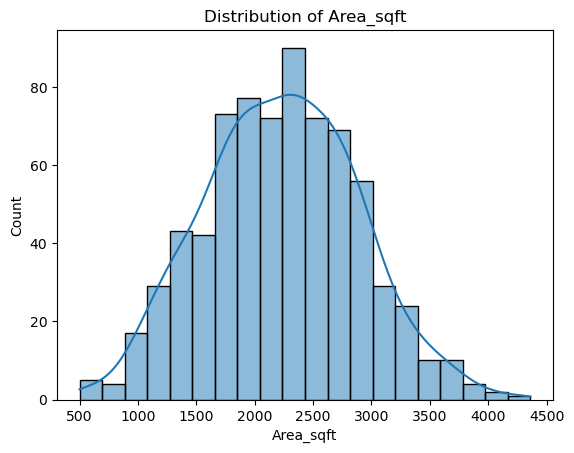

In [101]:
sns.histplot(df["Area_sqft"], kde=True)
plt.title("Distribution of Area_sqft")

In [102]:
df.groupby(["Property_Type" , "Garage_Type" , "Neighborhood" , "Has_Pool"])["Area_sqft"].mean()

Property_Type  Garage_Type  Neighborhood  Has_Pool
Apartment      Attached     Beach         No          2008.400000
                                          Yes         1773.000000
                            Downtown      No          2186.727273
                                          Yes         1996.750000
                            Industrial    No          1966.200000
                                                         ...     
Villa          Detached     Industrial    Yes         2564.500000
                            Rural         No          2335.500000
                                          Yes         2686.000000
                            Suburb        No          2245.333333
                                          Yes         1957.500000
Name: Area_sqft, Length: 73, dtype: float64

In [103]:
X = df.drop("Price", axis=1)
y = df["Price"]
X_train = X[0: 640]
y_train = y[0: 640]
X_test = X[640: ]
y_test = y[640: ]


In [104]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((640, 9), (640,), (160, 9), (160,))

In [105]:
X_train["Area_sqft"] = X_train["Area_sqft"].fillna(X_train.groupby(['Neighborhood', 'Property_Type'])['Area_sqft'].transform('mean'))
X_train["Area_sqft"] = X_train["Area_sqft"].fillna(X_train.groupby(['Property_Type', 'Garage_Type'])['Area_sqft'].transform('mean'))
X_train["Area_sqft"] = X_train["Area_sqft"].fillna(X_train.groupby('Property_Type')['Area_sqft'].transform('mean'))


mean_map1 = X_train.groupby(['Neighborhood', 'Property_Type'])['Area_sqft'].mean()
X_test["Area_sqft"] = X_test["Area_sqft"].fillna(X_test.set_index(['Neighborhood', 'Property_Type']).index.map(mean_map1).to_series(index=X_test.index))


mean_map2 = X_train.groupby(['Property_Type', 'Garage_Type'])['Area_sqft'].mean()
X_test["Area_sqft"] = X_test["Area_sqft"].fillna(X_test.set_index(['Property_Type', 'Garage_Type']).index.map(mean_map2).to_series(index=X_test.index))


mean_map3 = X_train.groupby('Property_Type')['Area_sqft'].mean()
X_test["Area_sqft"] = X_test["Area_sqft"].fillna(X_test['Property_Type'].map(mean_map3))

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\489451134.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\489451134.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\489451134.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

In [106]:
print(X_test["Area_sqft"].isnull().sum())

0


In [107]:
X_train.head()

,Area_sqft,Bedrooms,Bathrooms,Age,Neighborhood,Property_Type,Garage_Type,Has_Pool,Distance_to_Center
0,2761.0,3,1,24.0,Beach,House,Attached,No,8.1
1,1973.0,4,2,35.0,Downtown,Apartment,Attached,No,15.8
2,2616.0,3,1,22.0,Industrial,Apartment,NaN,Yes,10.5
3,2984.0,3,2,17.0,Rural,Townhouse,Attached,No,6.2
4,1938.0,2,2,26.0,Beach,Apartment,Detached,No,11.2


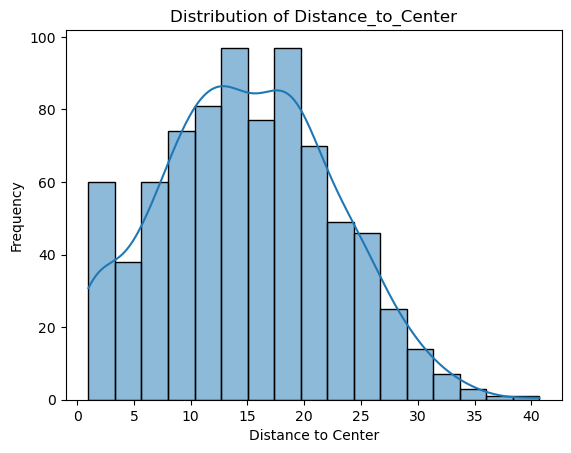

In [108]:
sns.histplot(df["Distance_to_Center"], kde=True)
plt.title("Distribution of Distance_to_Center")
plt.xlabel("Distance to Center")
plt.ylabel("Frequency")
plt.show()

In [109]:
X_train["Distance_to_Center"] = X_train["Distance_to_Center"].abs()
X_test["Distance_to_Center"] = X_test["Distance_to_Center"].abs()

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\292400217.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\292400217.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [110]:
X_train.describe()

,Area_sqft,Bedrooms,Bathrooms,Age,Distance_to_Center
count,640.000000,640.000000,640.000000,640.000000,640.000000
mean,2235.137320,3.004688,1.598437,30.546875,14.914062
std,624.125743,1.071020,0.682670,16.034909,7.569657
min,564.000000,1.000000,1.000000,1.000000,1.000000
25%,1823.500000,2.000000,1.000000,19.000000,9.475000
50%,2243.000000,3.000000,1.000000,31.000000,14.800000
75%,2658.250000,4.000000,2.000000,42.000000,20.100000
max,4362.000000,6.000000,4.000000,80.000000,40.700000


In [111]:
X_train["Distance_to_Center"] = X_train["Distance_to_Center"].fillna(X_train.groupby('Neighborhood')['Distance_to_Center'].transform('mean'))
X_train["Distance_to_Center"] = X_train["Distance_to_Center"].fillna(X_train["Distance_to_Center"].mean())


dist_mean_map = X_train.groupby('Neighborhood')['Distance_to_Center'].mean()
X_test["Distance_to_Center"] = X_test["Distance_to_Center"].fillna(X_test['Neighborhood'].map(dist_mean_map))

overall_dist_mean = X_train["Distance_to_Center"].mean()
X_test["Distance_to_Center"] = X_test["Distance_to_Center"].fillna(overall_dist_mean)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\2189583481.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\2189583481.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\2189583481.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

In [112]:
ranges = [0, 10, 20, np.inf]
labels = ['Close', 'Moderate', 'Far']

X_train['Distance_group'] = pd.cut(X_train['Distance_to_Center'], bins=ranges, labels=labels)
X_test['Distance_group'] = pd.cut(X_test['Distance_to_Center'], bins=ranges, labels=labels)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\2415862358.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\2415862358.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [113]:
X_train.head()

,Area_sqft,Bedrooms,Bathrooms,Age,Neighborhood,Property_Type,Garage_Type,Has_Pool,Distance_to_Center,Distance_group
0,2761.0,3,1,24.0,Beach,House,Attached,No,8.1,Close
1,1973.0,4,2,35.0,Downtown,Apartment,Attached,No,15.8,Moderate
2,2616.0,3,1,22.0,Industrial,Apartment,NaN,Yes,10.5,Moderate
3,2984.0,3,2,17.0,Rural,Townhouse,Attached,No,6.2,Close
4,1938.0,2,2,26.0,Beach,Apartment,Detached,No,11.2,Moderate


In [114]:
map_dict = {'No' : 0, 'Yes' : 1}
X_train['Has_Pool'] = X_train['Has_Pool'].map(map_dict)
X_test['Has_Pool'] = X_test['Has_Pool'].map(map_dict)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\1486912313.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\1486912313.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [115]:
print(X_train["Distance_to_Center"].isnull().sum())
print(X_test["Distance_to_Center"].isnull().sum())

0
0


In [116]:
X_train["Garage_Type"] = X_train["Garage_Type"].fillna(X_train.groupby(['Neighborhood', 'Property_Type'])['Garage_Type'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))
X_train["Garage_Type"] = X_train["Garage_Type"].fillna(X_train.groupby(['Property_Type'])['Garage_Type'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))
X_train["Garage_Type"] = X_train["Garage_Type"].fillna(X_train["Garage_Type"].mode()[0])


garage_mode_map = X_train.groupby('Property_Type')['Garage_Type'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
X_test["Garage_Type"] = X_test["Garage_Type"].fillna(X_test['Property_Type'].map(garage_mode_map))

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\1607780564.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\1607780564.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\1607780564.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

In [117]:
print(X_train["Garage_Type"].isnull().sum())
print(X_test["Garage_Type"].isnull().sum())

0
0


In [118]:
print("\nMissing Values per Column:\n", X_train.isnull().sum())
print("\nMissing Values per Column:\n", X_test.isnull().sum())


Missing Values per Column:
 Area_sqft             0
Bedrooms              0
Bathrooms             0
Age                   0
Neighborhood          0
Property_Type         0
Garage_Type           0
Has_Pool              0
Distance_to_Center    0
Distance_group        0
dtype: int64

Missing Values per Column:
 Area_sqft             0
Bedrooms              0
Bathrooms             0
Age                   0
Neighborhood          0
Property_Type         0
Garage_Type           0
Has_Pool              0
Distance_to_Center    0
Distance_group        0
dtype: int64


In [119]:
X_train["Age"] = X_train["Age"].fillna(X_train.groupby('Neighborhood')['Age'].transform('median'))
age_map = X_train.groupby('Neighborhood')['Age'].median()
X_test["Age"] = X_test["Age"].fillna(X_test['Neighborhood'].map(age_map))

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\1509516499.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\1509516499.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [120]:
print(X_train["Age"].isnull().sum())

0


## Detecting Outliers

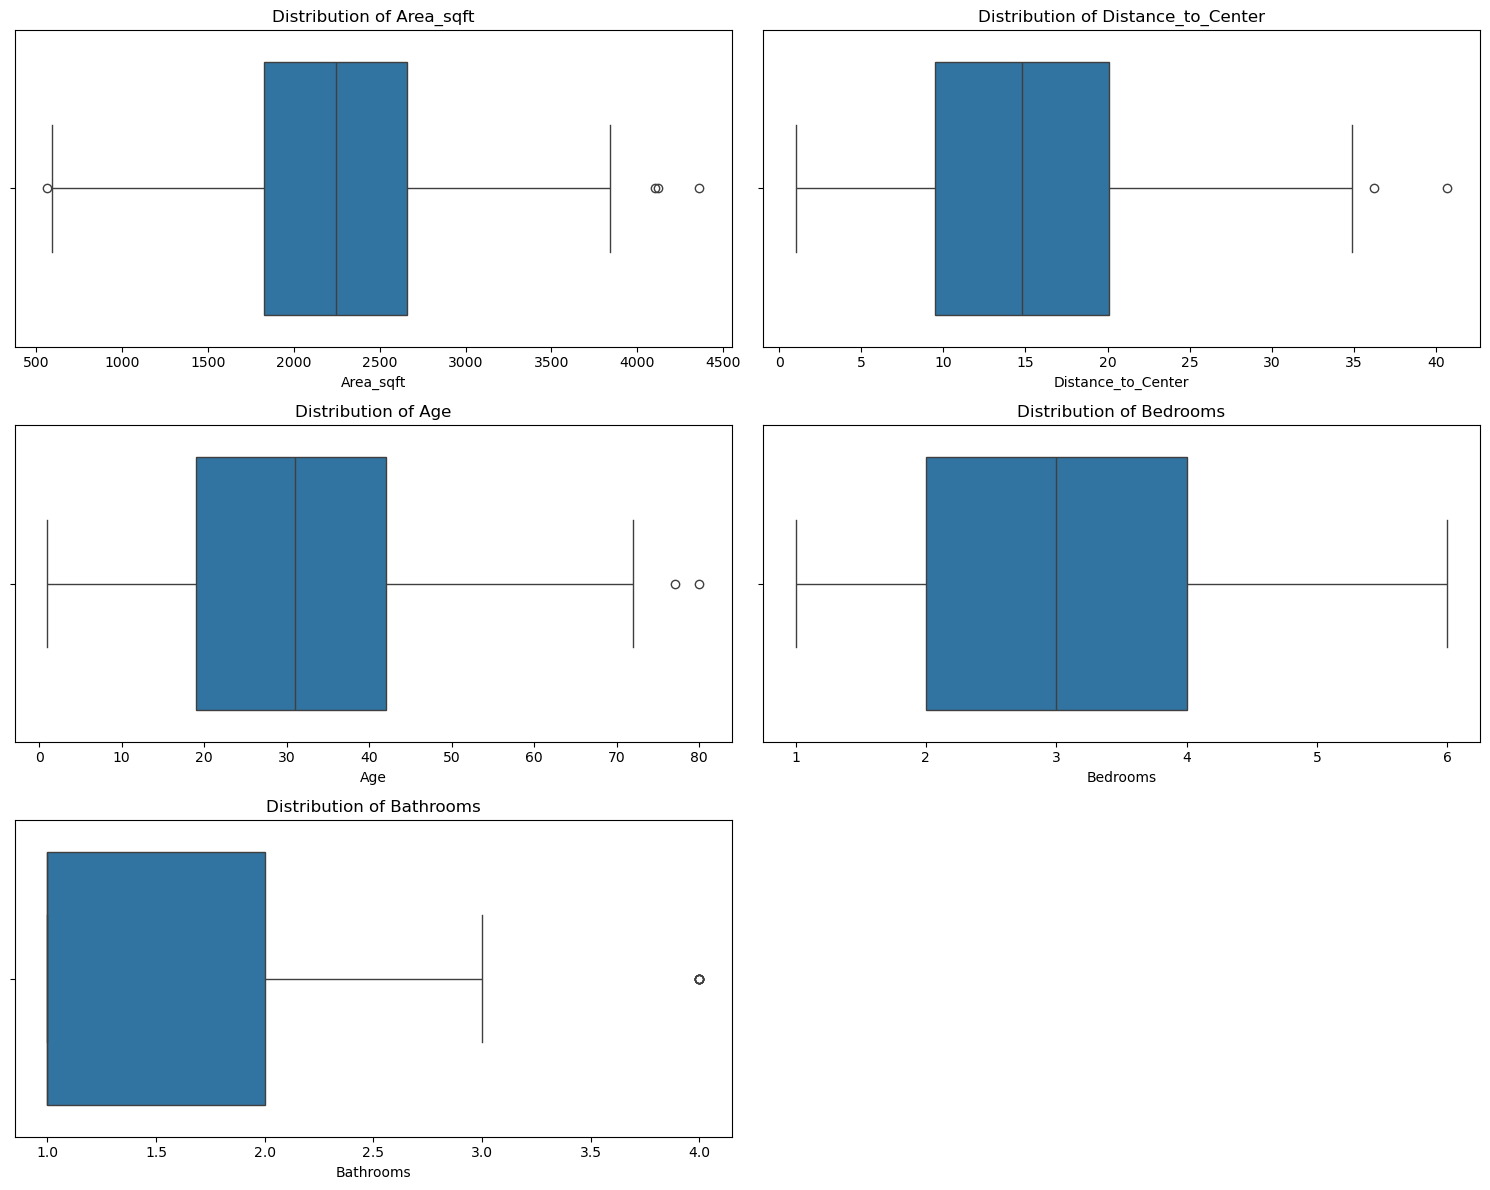

In [121]:
fig, ax = plt.subplots(3, 2, figsize=(15, 12)) 

ax_flat = ax.flatten()

cols = ['Area_sqft', 'Distance_to_Center', 'Age', 'Bedrooms', 'Bathrooms']

for i, col in enumerate(cols):
    sns.boxplot(x=X_train[col], ax=ax_flat[i])
    ax_flat[i].set_title(f"Distribution of {col}")
    ax_flat[i].set_xlabel(col)

if len(cols) < len(ax_flat):
    fig.delaxes(ax_flat[-1])

plt.tight_layout()
plt.show()

<Axes: xlabel='Price'>

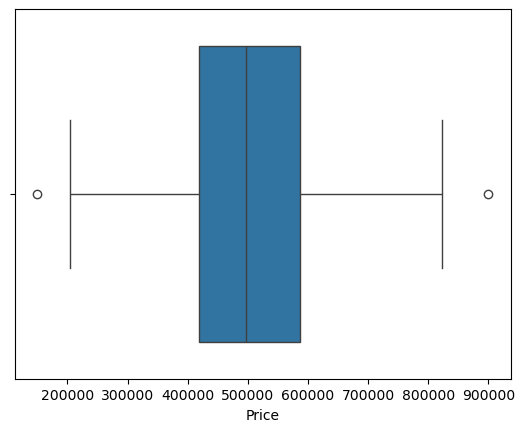

In [122]:
sns.boxplot(x=y_train)

In [123]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

In [124]:
outliers1 = detect_outliers_iqr(X_train, 'Area_sqft')
print(outliers1.shape[0])

4


In [125]:
outliers2 = detect_outliers_iqr(X_train, 'Distance_to_Center')
print(outliers2.shape[0])

2


In [126]:
print("% of outliers in Area_sqft:", (outliers1.shape[0] / X_train.shape[0]) * 100)
print("% of outliers in Distance_to_Center:", (outliers2.shape[0] / X_train.shape[0]) * 100)

% of outliers in Area_sqft: 0.625
% of outliers in Distance_to_Center: 0.3125


In [127]:
X_train = X_train.drop(outliers1.index)
X_train = X_train.drop(outliers2.index)
y_train = y_train.loc[X_train.index]

In [128]:
X_train.shape

(634, 10)

<Axes: xlabel='Price', ylabel='Count'>

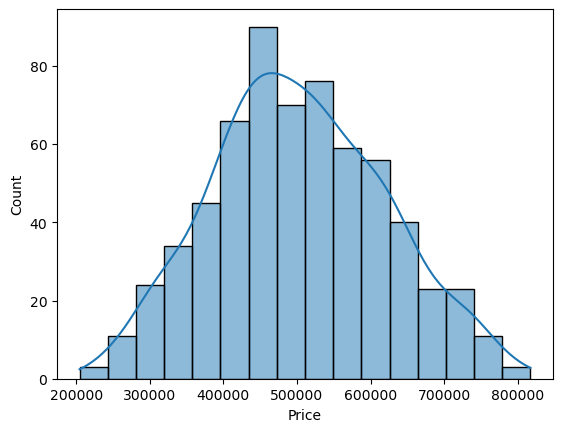

In [129]:
sns.histplot(y_train, kde=True)

In [130]:
X_train.head()

,Area_sqft,Bedrooms,Bathrooms,Age,Neighborhood,Property_Type,Garage_Type,Has_Pool,Distance_to_Center,Distance_group
0,2761.0,3,1,24.0,Beach,House,Attached,0,8.1,Close
1,1973.0,4,2,35.0,Downtown,Apartment,Attached,0,15.8,Moderate
2,2616.0,3,1,22.0,Industrial,Apartment,Attached,1,10.5,Moderate
3,2984.0,3,2,17.0,Rural,Townhouse,Attached,0,6.2,Close
4,1938.0,2,2,26.0,Beach,Apartment,Detached,0,11.2,Moderate


In [131]:
X_train["Neighborhood"].value_counts()  

Neighborhood
Suburb        227
Downtown      145
Rural         104
Beach          95
Industrial     63
Name: count, dtype: int64

In [132]:
X_train["Property_Type"].value_counts()

Property_Type
Townhouse    181
Villa        158
Apartment    148
House        147
Name: count, dtype: int64

In [133]:
X_train["Garage_Type"].value_counts()

Garage_Type
Attached    424
Detached    210
Name: count, dtype: int64

In [134]:
X_train["Distance_group"].value_counts()

Distance_group
Moderate    306
Close       170
Far         158
Name: count, dtype: int64

In [135]:
y_train.groupby(X_train['Neighborhood']).mean().sort_values(ascending=False)

Neighborhood
Downtown      510007.020690
Beach         507565.863158
Rural         505447.471154
Industrial    501332.968254
Suburb        495063.246696
Name: Price, dtype: float64

In [136]:
Neighborhood_price_map = {"Beach" : 5, "Downtown" : 4, "Suburb" : 3, "Industrial" : 2, "Rural" : 1}
X_train["Neighborhood"] = X_train["Neighborhood"].map(Neighborhood_price_map)
X_test["Neighborhood"] = X_test["Neighborhood"].map(Neighborhood_price_map)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\2677261219.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [137]:
y_train.groupby(X_train['Property_Type']).mean().sort_values(ascending=False)


Property_Type
House        517259.952381
Townhouse    501250.950276
Apartment    497295.020270
Villa        495799.670886
Name: Price, dtype: float64

In [138]:
Property_Type_price_map = {"Villa" : 4, "House" : 3, "Apartment" : 3, "Townhouse" : 1}
X_train["Property_Type"] = X_train["Property_Type"].map(Property_Type_price_map)
X_test["Property_Type"] = X_test["Property_Type"].map(Property_Type_price_map)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6280\2543959218.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [139]:
y_train.groupby(X_train['Garage_Type']).mean().sort_values(ascending=False)

Garage_Type
Detached    507540.785714
Attached    500273.775943
Name: Price, dtype: float64

In [140]:
X_train = pd.get_dummies(X_train, columns=['Garage_Type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Garage_Type'], drop_first=True)


X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [141]:
X_train[X_train.select_dtypes(include=['number', 'bool']).columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, 0 to 639
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Area_sqft             634 non-null    float64
 1   Bedrooms              634 non-null    int64  
 2   Bathrooms             634 non-null    int64  
 3   Age                   634 non-null    float64
 4   Neighborhood          634 non-null    int64  
 5   Property_Type         634 non-null    int64  
 6   Has_Pool              634 non-null    int64  
 7   Distance_to_Center    634 non-null    float64
 8   Garage_Type_Detached  634 non-null    bool   
dtypes: bool(1), float64(3), int64(5)
memory usage: 45.2 KB


In [142]:
all_num_cols = X_train.select_dtypes(include=['number', 'bool']).columns

In [143]:
# z-score normalization
train_mean = X_train[all_num_cols].mean()
train_std = X_train[all_num_cols].std()

X_train[all_num_cols] = (X_train[all_num_cols] - train_mean) / train_std
X_test[all_num_cols] = (X_test[all_num_cols] - train_mean) / train_std

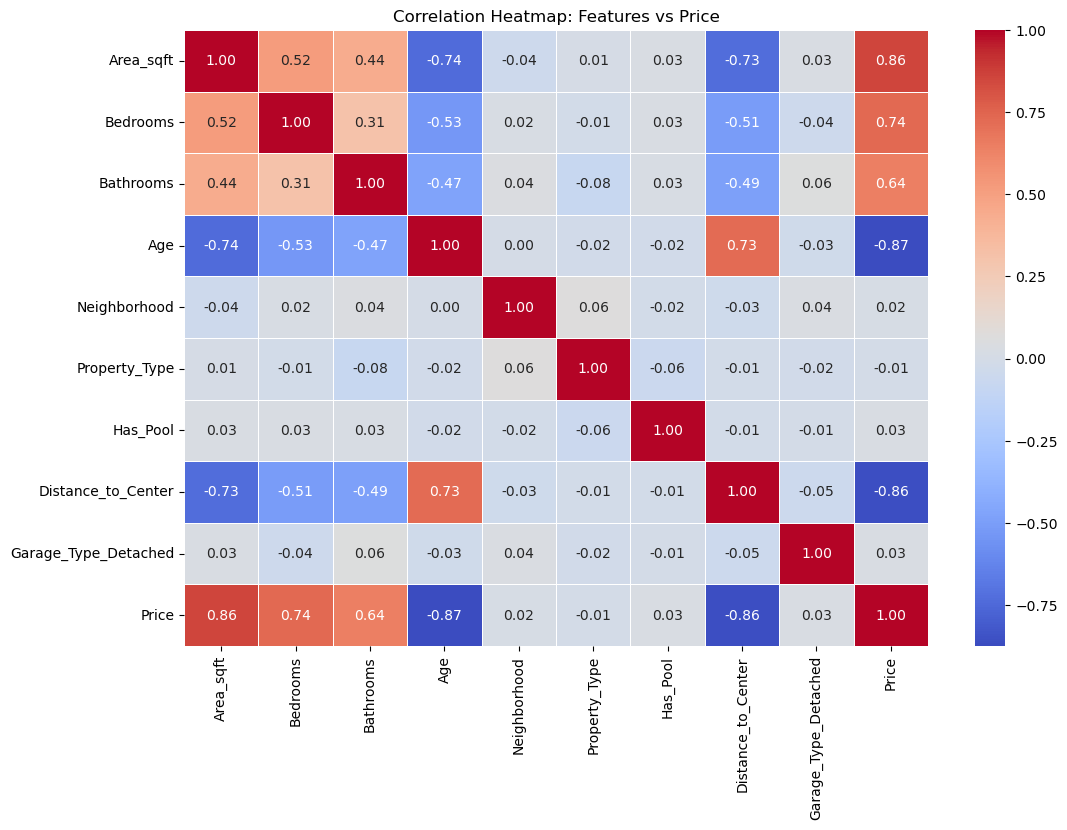

In [144]:
temp_df = X_train.copy()
temp_df['Price'] = y_train


corr_matrix = temp_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Features vs Price')
plt.show()

In [145]:
X_train.to_excel("X_train.xlsx", index=False)
y_train.to_excel("y_train.xlsx", index=False)
X_test.to_excel("X_test.xlsx", index=False)
y_test.to_excel("y_test.xlsx", index=False)

## Gradient descent and ML view

In [146]:
class MultiLinearRegressionGD: 

    def __init__(self):
        self.B_0            = None
        self.B              = None
        self.SSE            = None
        self.MSE            = None
        self.lambda_        = None
        self.regularization = None
        self.loss_history   = []
        self._feature_names = None
        self.R2 = None

    def fit(self, X, y, regularization='none', lambda_=0.0,
            learning_rate=0.01, epochs=1000, tolerance=1e-6):

        if isinstance(X, pd.DataFrame):
            self._feature_names = list(X.columns)
        else:
            self._feature_names = [f"X{i+1}" for i in range(np.array(X).shape[1])]

        if isinstance(X, pd.DataFrame) and isinstance(y, pd.Series):
            y = y.loc[X.index]

        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)
        n, p = X.shape

        self.regularization = regularization.lower()
        self.lambda_        = lambda_
        self.B_0            = 0.0
        self.B              = np.zeros(p)
        self.loss_history   = []
        prev_sse            = float('inf')

        for _ in range(epochs):
            y_hat = self.B_0 + X @ self.B
            error = y - y_hat
            dB_0  = (-2 / n) * np.sum(error)
            dB    = (-2 / n) * (X.T @ error)

            if self.regularization == 'ridge':
                dB += (2 * lambda_) * self.B
            elif self.regularization == 'lasso':
                dB += lambda_ * np.sign(self.B)

            self.B_0 -= learning_rate * dB_0
            self.B   -= learning_rate * dB

            sse = float(np.sum((y - self.predict(X)) ** 2))
            self.loss_history.append(sse)
            if abs(prev_sse - sse) < tolerance:
                break
            prev_sse = sse

        e = y - self.predict(X)
        self.SSE = float(np.sum(e ** 2))
        self.MSE = self.SSE / n
        y_mean = np.mean(y)
        sst = np.sum((y - y_mean) ** 2)
        self.R2 = 1 - (self.SSE / sst) if sst != 0 else 0

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self.B_0 + X @ self.B

    def plot(self, X, y):
        if isinstance(X, pd.DataFrame) and isinstance(y, pd.Series):
            y = y.loc[X.index]

        X      = np.asarray(X, dtype=float)
        y      = np.asarray(y, dtype=float).reshape(-1)
        y_pred = self.predict(X)

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f"MultiLinear GD | reg={self.regularization} λ={self.lambda_}",
                     fontsize=13, fontweight='bold')

        axes[0,0].plot(self.loss_history, color='steelblue')
        axes[0,0].set(title='Loss Curve', xlabel='Epoch', ylabel='SSE', yscale='log')
        axes[0,0].grid(True, alpha=0.3)

        axes[0,1].scatter(y, y_pred, alpha=0.5, s=20, color='steelblue')
        lo, hi = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
        axes[0,1].plot([lo,hi],[lo,hi],'r--')
        axes[0,1].set(title='Predicted vs Actual', xlabel='Actual y', ylabel='Predicted ŷ')
        axes[0,1].grid(True, alpha=0.3)

        axes[1,0].hist(y - y_pred, bins=30, color='salmon', edgecolor='white')
        axes[1,0].axvline(0, color='black', linestyle='--')
        axes[1,0].set(title='Residuals', xlabel='y − ŷ', ylabel='Frequency')
        axes[1,0].grid(True, alpha=0.3)

        idx = np.argsort(np.abs(self.B))[::-1][:12]
        colors = ['steelblue' if v >= 0 else 'salmon' for v in self.B[idx]]
        axes[1,1].barh([self._feature_names[i] for i in idx], self.B[idx], color=colors)
        axes[1,1].axvline(0, color='black', linewidth=0.8)
        axes[1,1].set(title='Coefficients', xlabel='Value')
        axes[1,1].grid(True, axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()

    def summary(self):
        print("Evaluation of the model")
        print("------------------------")
        print(f"Regularization : {self.regularization}  (λ = {self.lambda_})")
        print(f"Intercept B_0  : {round(self.B_0, 4)}")
        for i, (name, coef) in enumerate(zip(self._feature_names, self.B)):
            print(f"B_{i+1} ({name}) : {round(coef, 4)}")
        print(f"SSE : {round(self.SSE, 3)}")
        print(f"MSE : {round(self.MSE, 3)}")
        print(f"R^2 : {round(self.R2, 4)}")

In [147]:
distance_map = {'Close': 1, 'Moderate': 2, 'Far': 3}

X_train['Distance_group'] = X_train['Distance_group'].astype(str).map(distance_map).fillna(0).astype(int)
X_test['Distance_group']  = X_test['Distance_group'].astype(str).map(distance_map).fillna(0).astype(int)

Evaluation of the model
------------------------
Regularization : none  (λ = 0.0)
Intercept B_0  : 502658.2354
B_1 (Area_sqft) : 29290.532
B_2 (Bedrooms) : 32465.9489
B_3 (Bathrooms) : 23770.8752
B_4 (Age) : -32022.9244
B_5 (Distance_to_Center) : -28509.7152
SSE : 62840465095.613
MSE : 99117452.832
R^2 : 0.9928


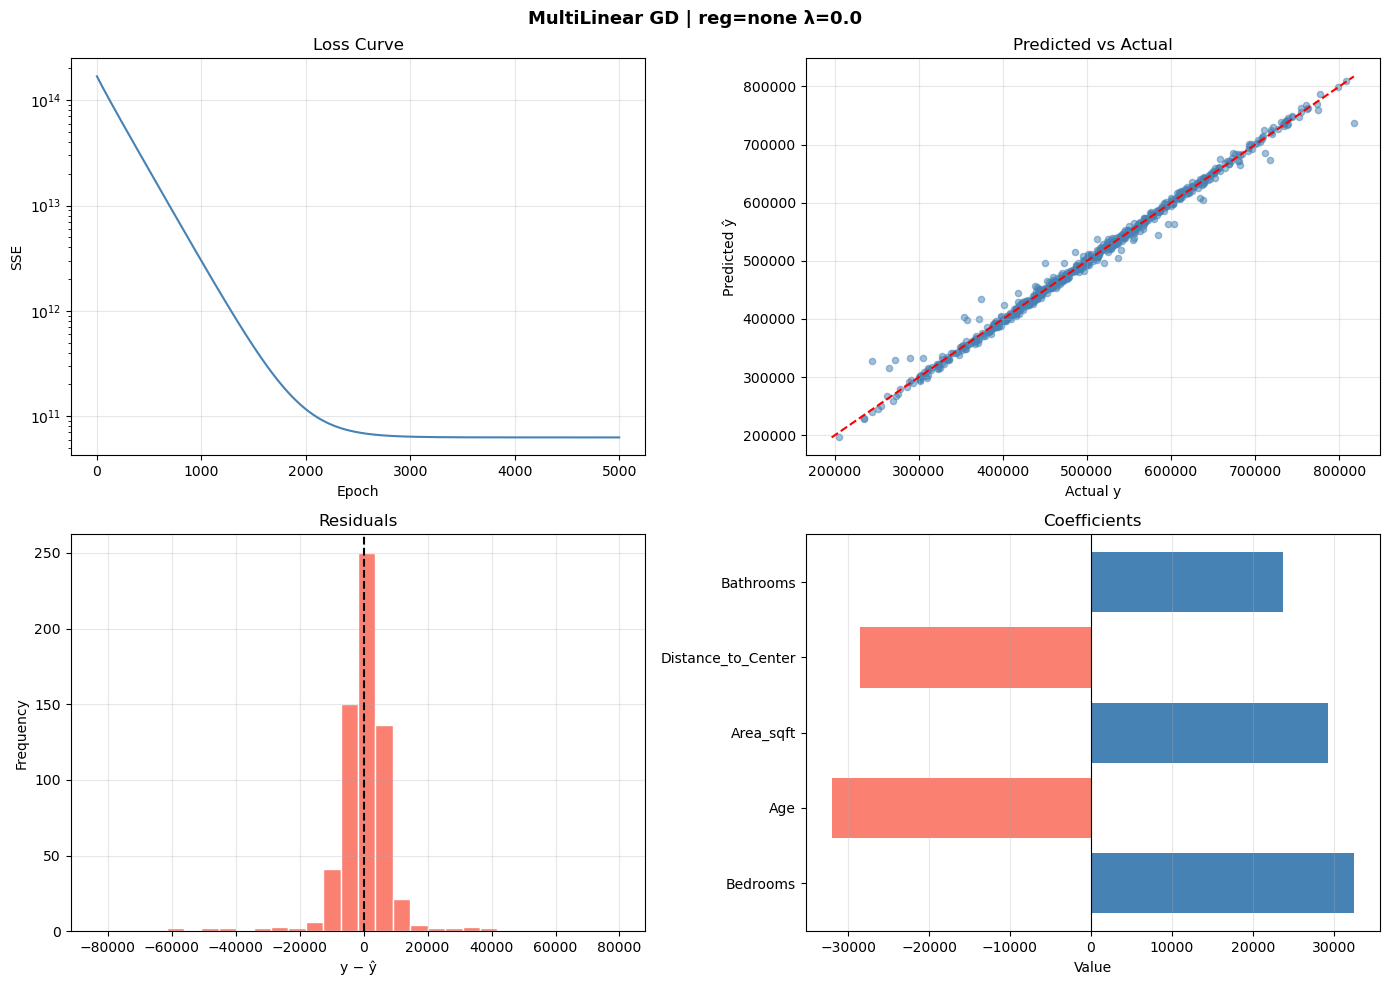

In [148]:
model = MultiLinearRegressionGD()
model.fit(X_train[[ "Area_sqft" , "Bedrooms" , "Bathrooms" , "Age" , "Distance_to_Center"]], y_train,
          regularization='none',
          lambda_=0.0,
          learning_rate=0.001,
          epochs=5000,
          tolerance=1e-8)
model.summary()
model.plot(X_train[[ "Area_sqft" , "Bedrooms" , "Bathrooms" , "Age" , "Distance_to_Center"]], y_train)

Evaluation of the model
------------------------
Regularization : none  (λ = 0.0)
Intercept B_0  : 502708.0925
B_1 (Area_sqft) : 28580.5335
B_2 (Bedrooms) : 33789.0725
B_3 (Bathrooms) : 23866.3692
B_4 (Age) : -31207.685
B_5 (Distance_to_Center) : -28627.8686
SSE : 25021013732.44
MSE : 156381335.828
R^2 : 0.9895


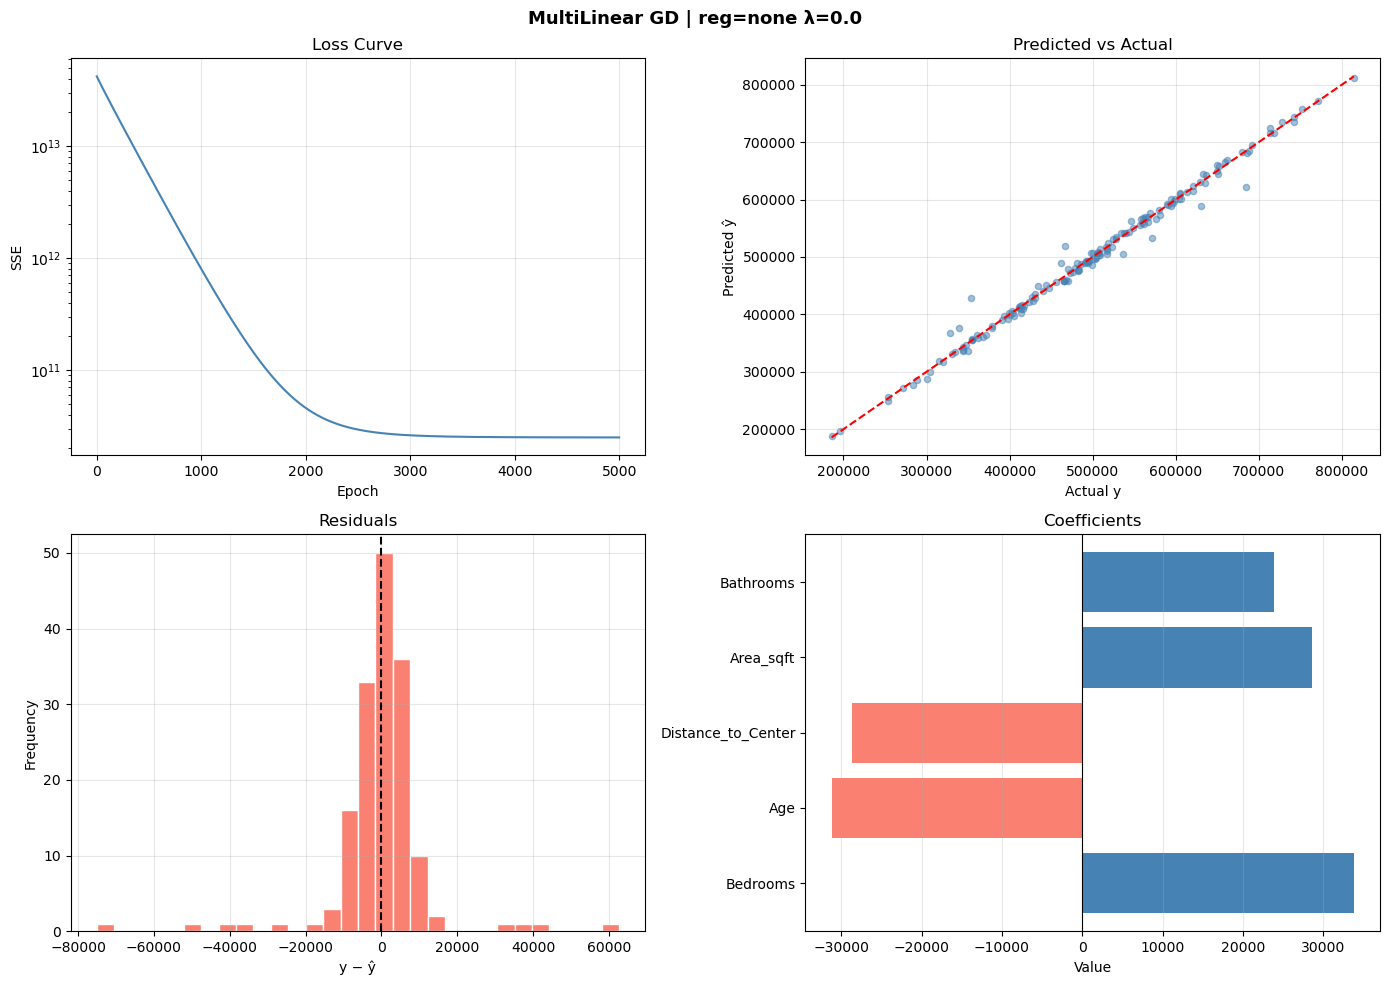

In [149]:
model= MultiLinearRegressionGD()
model.fit(X_test[[ "Area_sqft" , "Bedrooms" , "Bathrooms" , "Age" , "Distance_to_Center"]], y_test,
          regularization='none',
          lambda_=0.0,
          learning_rate=0.001,
          epochs=5000,
          tolerance=1e-8)
model.summary()
model.plot(X_test[[ "Area_sqft" , "Bedrooms" , "Bathrooms" , "Age" , "Distance_to_Center"]], y_test)

## Statistical view

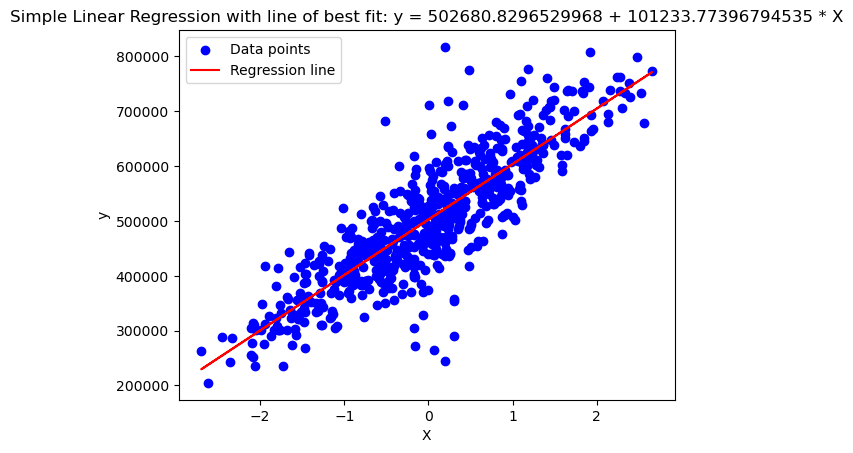

Model Performance:
------------------
Intercept (B0): 502680.8297
Slope (B1):     101233.7740
MSE:            3622503451.7130
R-squared:      0.7391 (73.91%)
Line of best fit is: y = 502680.830 + 101233.774 x
Mean squared error is: 3622503451.713


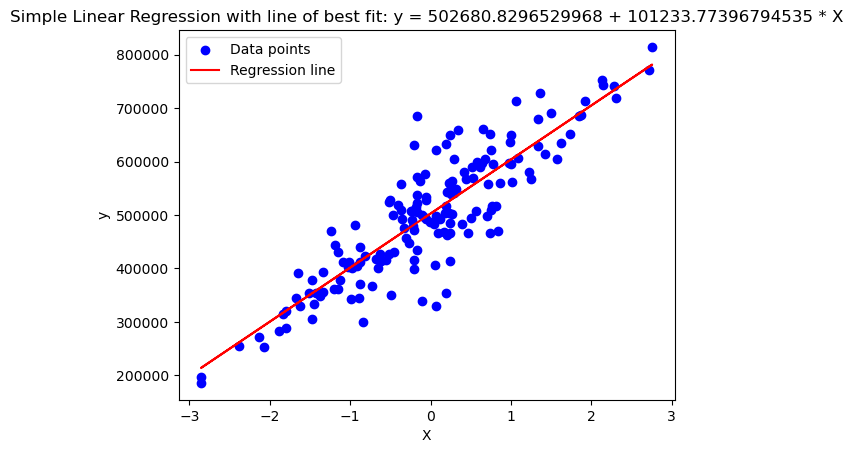

Test Set Performance:
---------------------
Test R-squared: 0.7788 (77.88%)
Test MSE:       3303733110.6751


In [150]:
class StatisticalModel:
    def __init__(self):
        self.B_0 = None
        self.B_1 = None
        self.MSE = None
        self.lambda_ = None
    
    def fit(self, X, y ,lambda_=0.0):
        X = np.array(X)
        y = np.array(y)
    # 2. Calculate the mean of X and y
        x_bar = X.mean()
        y_bar = y.mean()
        self.lambda_ = lambda_
    # 3. Calculate SXX and SXY
        SXX = np.sum(X**2) - len(X) * x_bar**2
        SXY = np.sum(X * y) - len(X) * x_bar * y_bar
    # 4. Calculate coefficients
        self.B_1 = SXY / (SXX + self.lambda_)
        self.B_0 = y_bar - self.B_1 * x_bar
    # 5. Calculate estimated error
        y_hat = self.predict(X)
        e = y - y_hat
        SSE = np.sum(e**2)
        self.MSE = SSE / (len(X) - 2)

    def predict(self, X):
        if self.B_0 is None or self.B_1 is None:
            raise ValueError("The model has not been fitted yet.")
        X = np.array(X)
        return self.B_0 + self.B_1 * X
    
    def plot(self, X, y):
        import matplotlib.pyplot as plt
        X = np.array(X)
        y = np.array(y)
        y_pred = self.predict(X)
        plt.scatter(X, y, color='blue', label='Data points')
        plt.plot(X, y_pred, color='red', label='Regression line')
        plt.xlabel('X')
        plt.ylabel('y')
        plt.title(f"Simple Linear Regression with line of best fit: "
                  f"y = {self.B_0} + {self.B_1} * X")
        plt.legend()
        plt.show()
    
    def score(self, X, y):
        y = np.array(y)
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        return r_squared



# Load the dataset — use x_slr/y_slr to avoid overwriting X_train
x_slr   = pd.read_excel('X_train.xlsx')["Area_sqft"]  
y_slr   = pd.read_excel('y_train.xlsx').squeeze()      
y_slr   = y_slr.iloc[:len(x_slr)]                     
# Fit the model
model_stat = StatisticalModel()
model_stat.fit(x_slr.values.flatten(), y_slr.values.flatten())

y_pred = model_stat.predict(x_slr.values.flatten())
model_stat.plot(x_slr.values.flatten(), y_slr.values.flatten())

r_squared = model_stat.score(x_slr.values.flatten(), y_slr.values.flatten())
print(f"Model Performance:")
print(f"------------------")
print(f"Intercept (B0): {model_stat.B_0:.4f}")
print(f"Slope (B1):     {model_stat.B_1:.4f}")
print(f"MSE:            {model_stat.MSE:.4f}")
print(f"R-squared:      {r_squared:.4f} ({r_squared*100:.2f}%)")
print(f'Line of best fit is: y = {model_stat.B_0:.3f} + {model_stat.B_1:.3f} x')
print(f'Mean squared error is: {model_stat.MSE:.3f}')

# Test dataset
X_test_vals = pd.read_excel('X_test.xlsx')["Area_sqft"].values.flatten()
y_test_vals = pd.read_excel('y_test.xlsx').squeeze().values.flatten()

y_test_pred = model_stat.predict(X_test_vals)
r2_test     = model_stat.score(X_test_vals, y_test_vals)
test_error  = y_test_vals - y_test_pred
mse_test    = np.sum(test_error**2) / len(X_test_vals)

model_stat.plot(X_test_vals, y_test_vals)
print(f"Test Set Performance:")
print(f"---------------------")
print(f"Test R-squared: {r2_test:.4f} ({r2_test*100:.2f}%)")
print(f"Test MSE:       {mse_test:.4f}")

## Numerical View


In [151]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleLinearRegressionNumericalView:

    def __init__(self):
        # Initialize model coefficients and metrics
        self.a0  = None
        self.a1  = None
        self.SSE = None
        self.MSE = None
        self.R2  = None
        self.lambda_ = None

    def predict(self, X):
        # Ensure input is a 1D numpy array and calculate predictions
        X = np.asarray(X, dtype=float).reshape(-1)
        return self.a0 + self.a1 * X
    
    @staticmethod
    def sse(y, y_hat):
        # Calculate Sum of Squared Errors
        return np.sum((y - y_hat) ** 2)

    def fit(self, X, y, show_steps=True , lambda_ = 0.0):
        # Pre-process inputs
        X = np.asarray(X, dtype=float).reshape(-1)
        y = np.asarray(y, dtype=float).reshape(-1)
        self.lambda_ = lambda_
        n = len(X)
        
        

        # Step 1: Compute basic summations for the normal equations
        Sx  = np.sum(X)
        Sy  = np.sum(y)
        Sxx = np.sum(X ** 2)
        Sxy = np.sum(X * y)
        
        # Scale regularisation penalty by dataset size n
        ridge_penalty = n * lambda_

        # Step 2: Solve the Normal Equations using Matrix Algebra
        # Matrix A contains coefficients of a0 and a1; vector b contains constants
        A = np.array([[n, Sx],[Sx, Sxx + ridge_penalty]], dtype=float)
        b = np.array([Sy, Sxy], dtype=float)
        self.a0, self.a1 = np.linalg.solve(A, b)

        # Step 3: Calculate evaluation metrics (SSE, MSE, and R-squared)
        y_hat    = self.predict(X)
        self.SSE = self.sse(y, y_hat)
        self.MSE = self.SSE / n
        
        # Calculate Total Sum of Squares (SST) for R2
        y_bar    = np.mean(y)
        SST      = np.sum((y - y_bar) ** 2)
        self.R2  = 1 - (self.SSE / SST)

        # Optional: Print the mathematical steps taken
        if show_steps:
            print("--- Step-by-Step Calculation ---")
            print(f"1. Summations: n={n}, Σx={Sx:.2f}, Σy={Sy:.2f}, Σx²={Sxx:.2f}, Σxy={Sxy:.2f}")
            print(f"2. Normal Equations Matrix:")
            print(f"   [[{n}, {Sx:.2f}], [{Sx:.2f}, {Sxx:.2f}]] [a0, a1] = [{Sy:.2f}, {Sxy:.2f}]")
            print(f"3. Results: a0 (Intercept) = {self.a0:.6f}, a1 (Slope) = {self.a1:.6f}")
            print(f"4. Metrics: SSE = {self.SSE:.4f}, MSE = {self.MSE:.4f}, R² = {self.R2:.4f}\n")

        return self

    def plot(self, X, y):
        # Visualize the data points and the regression line
        X = np.asarray(X, dtype=float).reshape(-1)
        y = np.asarray(y, dtype=float).reshape(-1)
        
        plt.scatter(X, y, color='blue', alpha=0.4, s=15, label='Data points')
        plt.plot(sorted(X), self.predict(sorted(X)), color='red',
                 label=f'ŷ = {self.a0:.2f} + {self.a1:.2f} * Area')
        
        plt.xlabel('Area (sqft)')
        plt.ylabel('Price')
        plt.title(f'Linear Regression (R² = {self.R2:.4f})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

--- Step-by-Step Calculation ---
1. Summations: n=634, Σx=0.00, Σy=318699646.00, Σx²=633.00, Σxy=64080978.92
2. Normal Equations Matrix:
   [[634, 0.00], [0.00, 633.00]] [a0, a1] = [318699646.00, 64080978.92]
3. Results: a0 (Intercept) = 502680.829653, a1 (Slope) = 101233.773968
4. Metrics: SSE = 2289422181482.6025, MSE = 3611075996.0293, R² = 0.7391



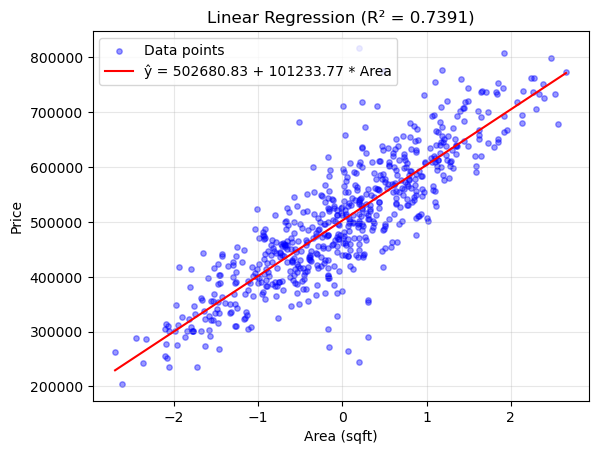

In [152]:
x = X_train['Area_sqft']
# y = y_train.loc[X_train.index]   # align after outlier removal

model = SimpleLinearRegressionNumericalView()
model.fit(x, y_train)
model.plot(x, y_train)

In [153]:
model.fit(X_test["Area_sqft"], y_test)

--- Step-by-Step Calculation ---
1. Summations: n=160, Σx=-5.56, Σy=79703055.00, Σx²=178.82, Σxy=15467620.17
2. Normal Equations Matrix:
   [[160, -5.56], [-5.56, 178.82]] [a0, a1] = [79703055.00, 15467620.17]
3. Results: a0 (Intercept) = 501690.364815, a1 (Slope) = 102092.278385
4. Metrics: SSE = 528299088837.9102, MSE = 3301869305.2369, R² = 0.7790



### Regularization

In [154]:

df_encoded = pd.get_dummies(df, columns=['Neighborhood', 'Property_Type', 'Garage_Type', 'Has_Pool'])

In [ ]:
import numpy as np

class RidgeRegression:
    def __init__(self, α=0.01, iterations=1000, λ=1):
        self.α = α
        self.iterations = iterations
        self.λ = λ

    def fit(self, X, y):
        self.n_samples, self.n_features = X.shape
        self.B1 = np.zeros(self.n_features)
        self.B0 = 0 

        for _ in range(self.iterations):
            y_pred = np.dot(X, self.B1) + self.B0
            
            
            dB1 = (1 / self.n_samples) * (np.dot(X.T, (y_pred - y)) + self.λ * self.B1)
            dB0 = (1 / self.n_samples) * np.sum(y_pred - y)

            self.B1-= self.α * dB1
            self.B0 -= self.α * dB0
    def predict(self, X):
        return np.dot(X, self.B1) + self.B0

In [156]:
class LassoRegression:
    def __init__(self, α=0.01, iterations=1000, λ=1):
        self.α = α
        self.iterations = iterations
        self.λ = λ

    def fit(self, X, y):
        self.n_samples, self.n_features = X.shape
        self.B1 = np.zeros(self.n_features)
        self.B0= 0

        for _ in range(self.iterations):
            y_pred = np.dot(X, self.B1) + self.B0
            
            
            dB1 = (1 / self.n_samples) * (np.dot(X.T, (y_pred - y)) + self.λ * np.sign(self.B1))
            dB0 = (1 / self.n_samples) * np.sum(y_pred - y)

            self.B1 -= self.α * dB1
            self.B0 -= self.α * dB0
    def predict(self, X):
         return np.dot(X, self.B1) + self.B0      

In [157]:
X_train = pd.DataFrame(X_train)
y_train = pd.Series(y_train.squeeze())

X_train, y_train = X_train.align(y_train, axis=0, join='inner')

In [158]:
print(X_train.shape)
print(y_train.shape)

(634, 10)
(634,)


In [159]:
df.sample(5)

,Area_sqft,Bedrooms,Bathrooms,Age,Neighborhood,Property_Type,Garage_Type,Has_Pool,Distance_to_Center,Price
242,2805.0,3,1,24.0,Downtown,House,Detached,Yes,9.1,547304
168,2042.0,3,2,37.0,Suburb,House,Attached,No,20.7,474525
149,2446.0,4,3,24.0,Rural,Townhouse,Attached,No,13.9,609691
750,1618.0,3,2,48.0,Beach,Townhouse,Attached,No,25.9,411270
606,1338.0,4,1,42.0,Downtown,Townhouse,Detached,No,19.0,423244


In [160]:
print(X_train.columns.tolist())

['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age', 'Neighborhood', 'Property_Type', 'Has_Pool', 'Distance_to_Center', 'Distance_group', 'Garage_Type_Detached']


In [161]:
cols = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age', 'Neighborhood', 
        'Property_Type', 'Has_Pool', 'Distance_to_Center', 
        'Distance_group', 'Garage_Type_Detached']

model = LassoRegression(α=0.001, iterations=2000, λ=10)
model.fit(X_train[cols], y_train)

print(f"B1: {model.B1}")
print(f"B0: {model.B0}")

B1: [ 50751.50263431  37876.06930658  32046.53992205 -50483.65098064
   3763.67813854   -253.75787531   2833.85243233 -94989.39886634
 179374.97469499   4138.98876372]
B0: 136519.8899989097


In [162]:
cols = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age', 'Neighborhood', 'Property_Type', 'Has_Pool', 'Distance_to_Center', 'Distance_group', 'Garage_Type_Detached']
model = RidgeRegression(α=0.001, iterations=2000, λ=10)
model.fit(X_train[cols], y_train)

print(f"B1: {model.B1}")
print(f"B0: {model.B0}")

B1: [ 50406.97429371  37673.64327768  31889.40189849 -50153.96657793
   3712.26010247   -249.15912182   2799.91883811 -93812.25432047
 177737.77075878   4088.87122205]
B0: 138487.85813650858


## Model Comparison

In [163]:
# Load the saved preprocessed splits 
X_train = pd.read_excel('X_train.xlsx')
X_test  = pd.read_excel('X_test.xlsx')
y_train = pd.read_excel('y_train.xlsx').values.flatten()
y_test  = pd.read_excel('y_test.xlsx').values.flatten()

#  Encode the only remaining categorical column: Distance_group 
# Label-encode: Close=0, Moderate=1, Far=2  (ordinal makes sense here)
dist_map = {'Close': 0, 'Moderate': 1, 'Far': 2}
X_train['Distance_group'] = X_train['Distance_group'].map(dist_map)
X_test['Distance_group']  = X_test['Distance_group'].map(dist_map)

#  Convert to NumPy arrays 
feature_names = X_train.columns.tolist()
X_tr = X_train.values.astype(float)
X_te = X_test.values.astype(float)

print("X_train shape:", X_tr.shape)
print("Features:", feature_names)

X_train shape: (634, 10)
Features: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age', 'Neighborhood', 'Property_Type', 'Has_Pool', 'Distance_to_Center', 'Distance_group', 'Garage_Type_Detached']


In [164]:
# Ridge and Lasso — same as before but now TRACK LOSS HISTORY for the GD plot

class RidgeRegression:
    def __init__(self, alpha=0.01, iterations=1000, lam=1):
        self.alpha = alpha
        self.iterations = iterations
        self.lam = lam
        self.loss_history = []

    def fit(self, X, y):
        n, p = X.shape
        self.B1 = np.zeros(p)
        self.B0 = 0
        self.loss_history = []

        for _ in range(self.iterations):
            y_pred = X @ self.B1 + self.B0
            error  = y_pred - y

            dB1 = (1/n) * (X.T @ error + self.lam * self.B1)
            dB0 = (1/n) * np.sum(error)

            self.B1 -= self.alpha * dB1
            self.B0 -= self.alpha * dB0

            self.loss_history.append(np.mean(error ** 2))   # MSE per iteration

    def predict(self, X):
        return X @ self.B1 + self.B0


class LassoRegression:
    def __init__(self, alpha=0.01, iterations=1000, lam=1):
        self.alpha = alpha
        self.iterations = iterations
        self.lam = lam
        self.loss_history = []

    def fit(self, X, y):
        n, p = X.shape
        self.B1 = np.zeros(p)
        self.B0 = 0
        self.loss_history = []

        for _ in range(self.iterations):
            y_pred = X @ self.B1 + self.B0
            error  = y_pred - y

            dB1 = (1/n) * (X.T @ error + self.lam * np.sign(self.B1))
            dB0 = (1/n) * np.sum(error)

            self.B1 -= self.alpha * dB1
            self.B0 -= self.alpha * dB0

            self.loss_history.append(np.mean(error ** 2))   # MSE per iteration

    def predict(self, X):
        return X @ self.B1 + self.B0


# Evaluation helpers 
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def adj_r2(y_true, y_pred, p):
    n  = len(y_true)
    r2_val = r2(y_true, y_pred)
    return 1 - (1 - r2_val) * (n - 1) / (n - p - 1)

print("Models defined.")

Models defined.


In [165]:
# DEFINE THE 3 MODEL SPECIFICATIONS
# Model 1 – Best Single Predictor: Age (highest absolute correlation with Price)
age_idx   = feature_names.index('Age')
X_tr_m1   = X_tr[:, [age_idx]]
X_te_m1   = X_te[:, [age_idx]]

# Model 2 – Full Model (all features)
X_tr_m2   = X_tr
X_te_m2   = X_te

# Model 3 – Domain Knowledge: the 4 most physically meaningful features
domain_features = ['Area_sqft', 'Bedrooms', 'Age', 'Distance_to_Center']
dom_idx   = [feature_names.index(f) for f in domain_features]
X_tr_m3   = X_tr[:, dom_idx]
X_te_m3   = X_te[:, dom_idx]

print("Model 1 – Best Predictor: Age")
print("Model 2 – Full Model:", len(feature_names), "features")
print("Model 3 – Domain Knowledge:", domain_features)

Model 1 – Best Predictor: Age
Model 2 – Full Model: 10 features
Model 3 – Domain Knowledge: ['Area_sqft', 'Bedrooms', 'Age', 'Distance_to_Center']


In [166]:
# FIT ALL 6 MODELS  (Ridge + Lasso for each specification)
PARAMS = dict(alpha=0.001, iterations=2000, lam=1)

ridge_m1 = RidgeRegression(**PARAMS); ridge_m1.fit(X_tr_m1, y_train)
ridge_m2 = RidgeRegression(**PARAMS); ridge_m2.fit(X_tr_m2, y_train)
ridge_m3 = RidgeRegression(**PARAMS); ridge_m3.fit(X_tr_m3, y_train)

lasso_m1 = LassoRegression(**PARAMS); lasso_m1.fit(X_tr_m1, y_train)
lasso_m2 = LassoRegression(**PARAMS); lasso_m2.fit(X_tr_m2, y_train)
lasso_m3 = LassoRegression(**PARAMS); lasso_m3.fit(X_tr_m3, y_train)

print("All 6 models fitted.")

All 6 models fitted.


In [167]:
# COMPARISON TABLE  –  R², Adjusted R², Number of predictors

rows = []
specs = [
    ("Model 1 – Best Single Predictor", X_te_m1, ridge_m1, lasso_m1, 1),
    ("Model 2 – Full Model",            X_te_m2, ridge_m2, lasso_m2, X_te_m2.shape[1]),
    ("Model 3 – Domain Knowledge",      X_te_m3, ridge_m3, lasso_m3, len(domain_features)),
]

for name, X_te_s, ridge, lasso, p in specs:
    for label, model in [("Ridge", ridge), ("Lasso", lasso)]:
        yhat = model.predict(X_te_s)
        rows.append({
            "Model Specification" : name,
            "Regularization"      : label,
            "# Predictors"        : p,
            "R²"                  : round(r2(y_test, yhat), 4),
            "Adjusted R²"         : round(adj_r2(y_test, yhat, p), 4),
        })

comparison_df = pd.DataFrame(rows)
comparison_df

,Model Specification,Regularization,# Predictors,R²,Adjusted R²
0,Model 1 – Best Single Predictor,Ridge,1,0.4982,0.4950
1,Model 1 – Best Single Predictor,Lasso,1,0.4983,0.4951
2,Model 2 – Full Model,Ridge,10,0.6370,0.6127
3,Model 2 – Full Model,Lasso,10,0.6366,0.6123
4,Model 3 – Domain Knowledge,Ridge,4,0.6709,0.6624
5,Model 3 – Domain Knowledge,Lasso,4,0.6709,0.6624


## Interactive Visualizations

All 5 charts are built with **Plotly** and are fully interactive.

1. Correlation heatmap across all numeric variables
2. Scatter plot – selectable X vs Price with fitted regression line
3. Gradient Descent convergence – loss vs iterations
4. Residual plots for all 3 model specifications
5. Coefficient bar chart comparing betas across model specs

In [168]:
# VIZ 1: Correlation Heatmap

# Build a dataframe with all numeric columns + Price
df_viz = X_train.copy()
df_viz['Price'] = y_train

corr = df_viz.corr().round(2)

fig1 = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Correlation Heatmap – All Numeric Variables',
    aspect='auto'
)
fig1.update_layout(width=850, height=650)
fig1.show()

In [169]:
# VIZ 2: Scatter Plot – selectable X vs Price with regression line
numeric_features = [c for c in X_train.columns]
y_vals = y_train

fig2 = go.Figure()

for col in numeric_features:
    x_vals = df_viz[col].values

    # Fit a simple OLS line from scratch (NumPy only)
    xm, ym = x_vals.mean(), y_vals.mean()
    slope     = np.sum((x_vals - xm) * (y_vals - ym)) / (np.sum((x_vals - xm)**2) + 1e-9)
    intercept = ym - slope * xm
    x_line    = np.linspace(x_vals.min(), x_vals.max(), 100)
    y_line    = slope * x_line + intercept

    fig2.add_trace(go.Scatter(
        x=x_vals, y=y_vals, mode='markers',
        name=col, visible=False,
        marker=dict(color='steelblue', opacity=0.5, size=5)
    ))
    fig2.add_trace(go.Scatter(
        x=x_line, y=y_line, mode='lines',
        name=f'{col} fit', visible=False,
        line=dict(color='crimson', width=2)
    ))

# Show first feature by default
fig2.data[0].visible = True
fig2.data[1].visible = True

# Dropdown
buttons = []
for i, col in enumerate(numeric_features):
    vis = [False] * len(fig2.data)
    vis[i*2], vis[i*2+1] = True, True
    buttons.append(dict(label=col, method='update',
                        args=[{'visible': vis}, {'xaxis': {'title': col}}]))

fig2.update_layout(
    title='Scatter Plot: Feature vs Price (with Regression Line)',
    xaxis_title=numeric_features[0],
    yaxis_title='Price',
    updatemenus=[dict(buttons=buttons, direction='down',
                      x=0.01, xanchor='left', y=1.15, yanchor='top', showactive=True)],
    width=800, height=500
)
fig2.show()

In [170]:
# VIZ 3: Gradient Descent Convergence – loss vs iterations
# We show the Lasso loss curves for all 3 model specs on the same chart

fig3 = go.Figure()

fig3.add_trace(go.Scatter(y=lasso_m1.loss_history, mode='lines',
                          name='Model 1 – Best Predictor (Age)',
                          line=dict(color='steelblue')))
fig3.add_trace(go.Scatter(y=lasso_m2.loss_history, mode='lines',
                          name='Model 2 – Full Model',
                          line=dict(color='darkorange')))
fig3.add_trace(go.Scatter(y=lasso_m3.loss_history, mode='lines',
                          name='Model 3 – Domain Knowledge',
                          line=dict(color='green')))

fig3.update_layout(
    title='Gradient Descent Convergence – MSE Loss vs Iterations (Lasso)',
    xaxis_title='Iteration',
    yaxis_title='MSE Loss',
    width=800, height=450
)
fig3.show()

In [171]:
# VIZ 4: Residual Plots – one per model specification (Ridge) 

yhat_r1 = ridge_m1.predict(X_te_m1)
yhat_r2 = ridge_m2.predict(X_te_m2)
yhat_r3 = ridge_m3.predict(X_te_m3)

res1 = y_test - yhat_r1
res2 = y_test - yhat_r2
res3 = y_test - yhat_r3

fig4 = make_subplots(rows=1, cols=3,
                     subplot_titles=['Model 1 – Best Predictor',
                                     'Model 2 – Full Model',
                                     'Model 3 – Domain Knowledge'])

for col_i, (yhat, res, color) in enumerate(
        [(yhat_r1, res1, 'steelblue'),
         (yhat_r2, res2, 'darkorange'),
         (yhat_r3, res3, 'green')], start=1):

    fig4.add_trace(go.Scatter(x=yhat, y=res, mode='markers',
                              marker=dict(color=color, opacity=0.5, size=5),
                              showlegend=False),
                   row=1, col=col_i)
    # Zero reference line
    fig4.add_trace(go.Scatter(x=[yhat.min(), yhat.max()], y=[0, 0],
                              mode='lines', line=dict(color='red', dash='dash'),
                              showlegend=False),
                   row=1, col=col_i)

fig4.update_xaxes(title_text='Fitted Values')
fig4.update_yaxes(title_text='Residuals', col=1)
fig4.update_layout(
    title='Residual Plots – Ridge Regression (all 3 Specifications)',
    height=400, width=1050, showlegend=False
)
fig4.show()

In [172]:
# VIZ 5: Coefficient Bar Chart – Ridge betas across model specs 

# Only features that appear in at least one spec are shown
# We align everything to the full feature list for a fair side-by-side comparison

all_feats = feature_names

# Build coefficient arrays aligned to all_feats (0 if not in that spec)
def aligned_betas(model, cols_used):
    betas = np.zeros(len(all_feats))
    for val, col in zip(model.B1, cols_used):
        betas[all_feats.index(col)] = val
    return betas

beta_m1 = aligned_betas(ridge_m1, ['Age'])
beta_m2 = aligned_betas(ridge_m2, all_feats)
beta_m3 = aligned_betas(ridge_m3, domain_features)

fig5 = go.Figure()
fig5.add_trace(go.Bar(x=all_feats, y=beta_m1, name='Model 1 – Best Predictor', marker_color='steelblue'))
fig5.add_trace(go.Bar(x=all_feats, y=beta_m2, name='Model 2 – Full Model',     marker_color='darkorange'))
fig5.add_trace(go.Bar(x=all_feats, y=beta_m3, name='Model 3 – Domain Knowledge', marker_color='green'))

fig5.update_layout(
    title='Coefficient Comparison – Ridge Betas across Model Specifications',
    xaxis_title='Feature',
    yaxis_title='Coefficient (Beta)',
    barmode='group',
    width=950, height=450
)
fig5.show()